# 11｜人工神經網路入門

對應 `slides/11_人工神經網路入門.md`。本檔由 `16_人工神經網路入門.ipynb` 改名，程式與已執行輸出保留。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import ROOT, DATA, OUT, SEED, FAST, setup, savefig, report, data_path
setup()

{'profile': 'fast',
 'seed': 42,
 'data': '/Users/leonjye/Documents/MacProject/MLCourse2026/programs/data'}

## 1. Perceptron：答錯才修正

TLU 是「加權和 + 偏置 + 階躍」。Perceptron 學習規則只在預測錯時把權重往正確方向推。線性可分時會收斂（教材式 9-3）。

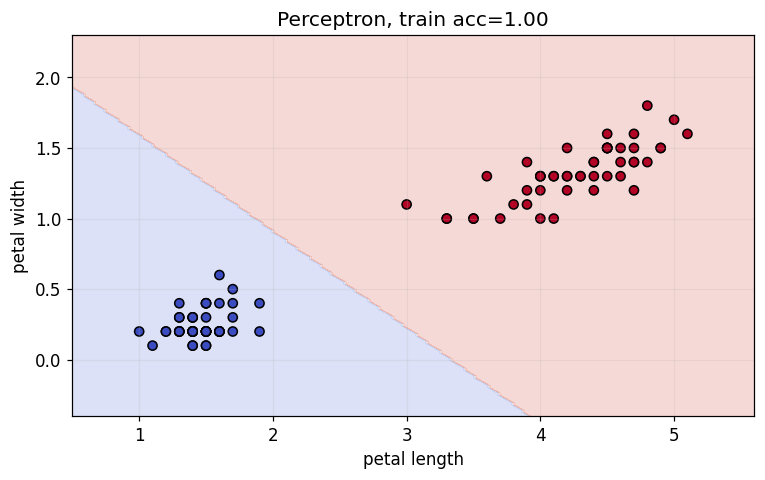

In [2]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
iris = load_iris()
mask = iris.target != 2                       # setosa vs versicolor，線性可分
X, y = iris.data[mask][:, 2:4], iris.target[mask]
per = Perceptron(random_state=SEED).fit(X, y)
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - .5, X[:, 0].max() + .5, 200),
                     np.linspace(X[:, 1].min() - .5, X[:, 1].max() + .5, 200))
zz = per.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, zz, alpha=.2, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel('petal length'); plt.ylabel('petal width'); plt.title(f'Perceptron, train acc={per.score(X, y):.2f}')
savefig('16_perceptron')
assert per.score(X, y) == 1.0

## 2. 手算驗算：XOR 網路的四組輸入

對應投影片活動。$h_1=\operatorname{step}(A+B-1.5)$、$h_2=\operatorname{step}(A+B-0.5)$、$\hat y=\operatorname{step}(-h_1+h_2-0.5)$。

In [3]:
step = lambda v: (v >= 0).astype(int)
rows = []
for A in [0, 1]:
    for B in [0, 1]:
        h1 = step(np.array(A + B - 1.5)); h2 = step(np.array(A + B - 0.5))
        yhat = int(step(np.array(-h1 + h2 - 0.5)))
        rows.append({'A': A, 'B': B, 'h1': int(h1), 'h2': int(h2), 'y_hat': yhat, 'XOR': A ^ B})
xor = pd.DataFrame(rows)
assert (xor.y_hat == xor.XOR).all()          # 隱藏層把不可線性分的問題轉成可分表示
xor

,A,B,h1,h2,y_hat,XOR
0,0,0,0,0,0,0
1,0,1,0,1,1,1
2,1,0,0,1,1,1
3,1,1,1,1,0,0


## 3. 激活函數與其導數

沒有非線性，堆再多層也會折成一層（教材 p.299）。ReLU 在正半軸導數為 1，緩解梯度衰減；sigmoid／tanh 兩端飽和。

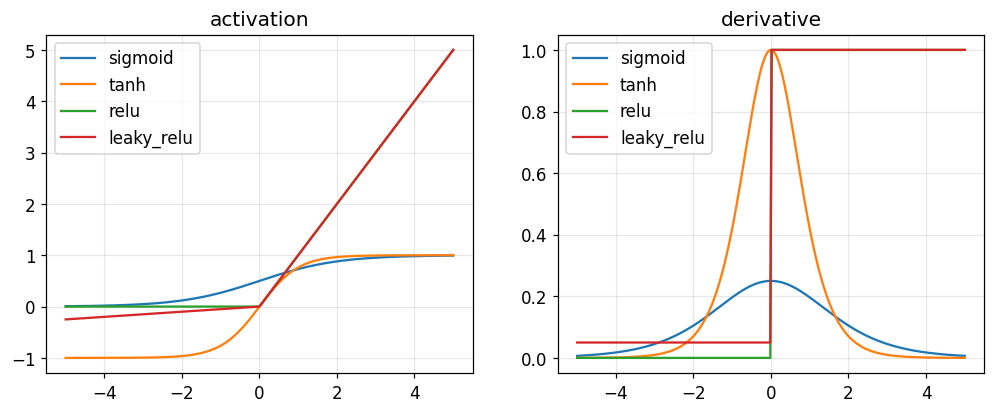

In [4]:
from scipy.special import expit
z = np.linspace(-5, 5, 300)
acts = {'sigmoid': (expit(z), expit(z) * (1 - expit(z))),
        'tanh': (np.tanh(z), 1 - np.tanh(z) ** 2),
        'relu': (np.maximum(0, z), (z > 0).astype(float)),
        'leaky_relu': (np.where(z > 0, z, .05 * z), np.where(z > 0, 1.0, .05))}
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, (f, d) in acts.items():
    axes[0].plot(z, f, label=name); axes[1].plot(z, d, label=name)
axes[0].set_title('activation'); axes[1].set_title('derivative')
for ax in axes:
    ax.legend(); ax.grid(alpha=.3)
savefig('16_activations')
assert np.isclose(expit(0.0) * (1 - expit(0.0)), 0.25)         # sigmoid 導數在 z=0 最大 0.25

## 4. 手算驗算：一個 sigmoid 神經元的前向與反向

對應投影片兩個活動。$x=2,\;w=.5,\;b=0,\;y=1$，$L=\frac12(a-y)^2$。

In [5]:
x, w, b, y = 2.0, 0.5, 0.0, 1.0
z = w * x + b
a = float(expit(z))
L = 0.5 * (a - y) ** 2
dL_dz = (a - y) * a * (1 - a)                 # (a-y)·σ'(z)
dL_dw = dL_dz * x
dL_db = dL_dz
w_new = w - 0.1 * dL_dw
b_new = b - 0.1 * dL_db
a_new = float(expit(w_new * x + b_new))
L_new = 0.5 * (a_new - y) ** 2
assert np.isclose(a, 0.7310586, atol=1e-6) and np.isclose(L, 0.0361650, atol=1e-6)
assert np.isclose(dL_dz, -0.0528775, atol=1e-6) and np.isclose(dL_dw, -0.1057550, atol=1e-6)
assert np.isclose(w_new, 0.5105755, atol=1e-6) and np.isclose(b_new, 0.0052877, atol=1e-6)
assert np.isclose(L_new, 0.0347895, atol=1e-5) and L_new < L        # 損失下降
pd.Series({'z': z, 'a': a, 'L': L, 'dL_dz': dL_dz, 'dL_dw': dL_dw, 'dL_db': dL_db,
           'w_new': w_new, 'b_new': b_new, 'L_after_update': L_new})

z                 1.000000
a                 0.731059
L                 0.036165
dL_dz            -0.052877
dL_dw            -0.105754
dL_db            -0.052877
w_new             0.510575
b_new             0.005288
L_after_update    0.034789
dtype: float64

## 5. 手算驗算：網路形狀與參數數目

對應投影片離線題：10 輸入 → 50 隱藏 → 3 輸出。

In [6]:
n_in, n_hidden, n_out = 10, 50, 3
params = {'W1': n_in * n_hidden, 'b1': n_hidden, 'W2': n_hidden * n_out, 'b2': n_out}
total = sum(params.values())
assert total == 703
print('per-layer parameters:', params, ' total:', total)
print('batch shapes for m examples: X (m,10) -> hidden (m,50) -> output (m,3)')

per-layer parameters: {'W1': 500, 'b1': 50, 'W2': 150, 'b2': 3}  total: 703
batch shapes for m examples: X (m,10) -> hidden (m,50) -> output (m,3)


## 6. 用 numpy 訓練小型 MLP（改編自 leonjye NeuralNetMLP）

sigmoid 隱藏層 + sigmoid 輸出、MSE 損失、one-hot 目標、mini-batch。縮到 digits（8×8）以便課堂即時跑。

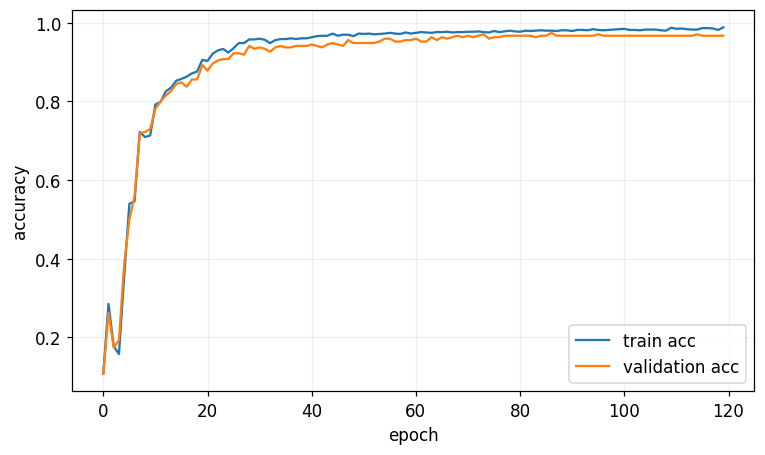

hand-written MLP test accuracy: 0.962


In [7]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
digits = load_digits()
Xd = digits.data / 16.0
Xtr, Xte, ytr, yte = train_test_split(Xd, digits.target, test_size=.25, stratify=digits.target, random_state=SEED)
Xtr, Xval, ytr, yval = train_test_split(Xtr, ytr, test_size=.2, stratify=ytr, random_state=SEED)

def onehot(y, k=10):
    o = np.zeros((len(y), k)); o[np.arange(len(y)), y] = 1; return o

class TinyMLP:
    def __init__(self, n_in, n_hidden, n_out, seed=SEED):
        rng = np.random.default_rng(seed)
        self.Wh = rng.normal(0, 0.1, (n_hidden, n_in)); self.bh = np.zeros(n_hidden)
        self.Wo = rng.normal(0, 0.1, (n_out, n_hidden)); self.bo = np.zeros(n_out)
    def forward(self, X):
        self.ah = expit(X @ self.Wh.T + self.bh)
        self.ao = expit(self.ah @ self.Wo.T + self.bo)
        return self.ao
    def step(self, X, y, lr):
        ao = self.forward(X); Y = onehot(y)
        delta_o = 2 * (ao - Y) / len(y) * ao * (1 - ao)          # dL/dz_out
        delta_h = (delta_o @ self.Wo) * self.ah * (1 - self.ah)
        self.Wo -= lr * delta_o.T @ self.ah; self.bo -= lr * delta_o.sum(0)
        self.Wh -= lr * delta_h.T @ X;       self.bh -= lr * delta_h.sum(0)
    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

net = TinyMLP(64, 40, 10)
rng = np.random.default_rng(SEED); hist = []
for epoch in range(120):
    idx = rng.permutation(len(Xtr))
    for s in range(0, len(Xtr), 32):
        b = idx[s:s + 32]
        net.step(Xtr[b], ytr[b], lr=0.5)
    hist.append((np.mean(net.predict(Xtr) == ytr), np.mean(net.predict(Xval) == yval)))
hist = np.array(hist)
plt.plot(hist[:, 0], label='train acc'); plt.plot(hist[:, 1], label='validation acc')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend()
savefig('16_tiny_mlp_training')
tiny_test_acc = float(np.mean(net.predict(Xte) == yte))
assert tiny_test_acc > 0.9
print('hand-written MLP test accuracy:', round(tiny_test_acc, 3))

## 7. scikit-learn MLP 與簡單模型比較

同一切分：`MLPClassifier` 兩種隱藏層設定 vs 標準化 logistic。比較 accuracy、log loss、訓練時間與錯誤案例。訓練損失、驗證分數與測試指標不可混用。

In [8]:
import time
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss

models = {'logistic_std': make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
          'mlp_(32,)': make_pipeline(StandardScaler(), MLPClassifier((32,), max_iter=400, early_stopping=True, random_state=SEED)),
          'mlp_(32,16)': make_pipeline(StandardScaler(), MLPClassifier((32, 16), max_iter=400, early_stopping=True, random_state=SEED))}
rows = []
for name, m in models.items():
    t0 = time.perf_counter(); m.fit(np.vstack([Xtr, Xval]), np.concatenate([ytr, yval])); fit_s = time.perf_counter() - t0
    proba = m.predict_proba(Xte)
    rows.append({'model': name, 'test_accuracy': accuracy_score(yte, m.predict(Xte)),
                 'test_log_loss': log_loss(yte, proba), 'fit_seconds': round(fit_s, 2)})
compare = pd.DataFrame(rows).set_index('model')

# 一個小型迴歸 MLP（教材圖 9-9）
rng = np.random.default_rng(SEED)
Xr = rng.uniform(-3, 3, (400, 1)); yr = np.sin(Xr[:, 0]) + 0.3 * Xr[:, 0] + rng.normal(0, .1, 400)
Xrtr, Xrte, yrtr, yrte = train_test_split(Xr, yr, test_size=.3, random_state=SEED)
reg = make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=(50, 50), early_stopping=True,
                                                   max_iter=500, random_state=SEED)).fit(Xrtr, yrtr)
from sklearn.metrics import root_mean_squared_error
reg_rmse = float(root_mean_squared_error(yrte, reg.predict(Xrte)))

report('neural_networks', {'xor_check': xor.to_dict('records'),
       'sigmoid_neuron': {'a': a, 'L': L, 'L_after_update': L_new},
       'param_count_10_50_3': total, 'tiny_mlp_test_accuracy': tiny_test_acc,
       'model_comparison': compare.to_dict(), 'mlp_regressor_test_RMSE': reg_rmse})
compare

,test_accuracy,test_log_loss,fit_seconds
model,,,
logistic_std,0.977778,0.103485,0.01
"mlp_(32,)",0.942222,0.252209,0.06
"mlp_(32,16)",0.940000,0.277436,0.07


## 練習與參考答案

- 梯度是新參數嗎？**否，梯度只給方向與大小，更新是另一步（$\theta \leftarrow \theta - \eta\,\nabla$）。**
- 為什麼隱藏層要隨機初始化？**全相同會讓隱藏神經元學到一樣的東西，打不破對稱。**
- softmax 多類別與多標籤差在哪？**類別互斥性不同；多標籤各標籤用 sigmoid。**
- 小型 MLP 贏過 logistic 就一定要用 MLP 嗎？**要確認額外複雜度帶來的泛化收益值得，並看訓練時間與可解釋性。**